## Overview

This notebook is intended to:

* Display the number of meters per phase in a given grid.
* Display the number of meters per consumer type in a given grid.
* Display the number of meters per phase and consumer type combination in a given grid. 

This snippet notebook is designed as follows:

* Define the grid of interest.
* Call the REST API endpoint to get all the meters and their attributes in the grid of interest. 
* Aggregate the results by phase. Display and plot the outcome. 
* Aggregate the results by consumer type. Display and plot the outcome. 
* Aggregate the results by phase and consumer type. Display and plot the outcome. 

The insights derived from these results may be helpful in multiple use cases ranging from Data Quality Improvement to Grid Planning or Customer Analytics. 

It is assumed that the user has been given credentials for accessing the Awesense Sandbox. Otherwise, please contact us at [api@awesense.com](api@awesense.com).

You can find more information about how to use Awesense's REST API in the [access_and_basic_data_retrieval](https://github.com/Awesense/edm-app-examples/blob/master/intro_and_tutorials/rest_api/access_and_basic_data_retrieval.ipynb) notebook.

---

## Setup

In [1]:
import getpass

import pandas as pd
import plotly.express as px
import requests

pd.set_option('display.max_columns', None)

### Connection

Enter the login credentials provided by Awesense. If you do not have the credentials or have any trouble connecting, please contact api@awesense.com.
<span style='color:red'> **Please do NOT store the credentials in the notebook, nor share them with anyone.** </span>

In [2]:
# Enter the REST server origin or hostname (optionally without "https://")
server_hostname = getpass.getpass(prompt='REST server address: ')
# Ensure that the server address does not specify plaintext HTTP
assert (server_hostname.startswith('http://') == False), 'Server address uses https:// for secure communications, not http://'

# Support the case where the specified address already included `https://`, otherwise add it
if server_hostname.startswith('https://'):
    server_origin = server_hostname
else:
    server_origin = f'https://{server_hostname}'

REST server address:  ········


In [3]:
# Enter the username that you use to log into the server
server_user_name = getpass.getpass(prompt='Username: ')

Username:  ········


In [4]:
# Enter the password that you use to log into the server
server_password = getpass.getpass(prompt='Password: ')

Password:  ········


In [5]:
# This auth tuple can be passed to `requests` functions as the `auth` argument.
# (An HTTP Basic Authentication header will be generated and used automatically)
auth = (server_user_name, server_password)

---

## Meter Count per Phase and Consumer Type

#### Input Parameters
Enter the grid ID of interest.

In [6]:
grid_id = input('Enter grid ID: ') # e.g. North Central Zone

Enter grid ID:  North Central Zone


#### Retrieve all Meter Information from the Endpoint

In [7]:
# Get all the `grid_elements` of type `Meter`. 
grid_element_type = 'Meter'

params = {
        'limit': '30000',
        'offset': '0', 
        'ordering': '{"direction": "ASC", "query_name": "grid_id"}',
        'filter': f'{{"operator": "=", "column_name": "grid_id", "value": "{grid_id}"}}',
        'export': 'false',
        'grid_element_type': grid_element_type,
}

response = requests.get(f'{server_origin}/api/v1/grid_explorer', auth=auth, params=params)
grid_elements = pd.json_normalize(response.json())
grid_elements

,headers,results,counts.filtered,counts.total
0,"[{'filterable': True, 'list': False, 'name': '...","[{'address': '3755 E Hartman Rd', 'business_id...",20967,20994


#### Meter Count by Phase

In [8]:
# Unpack the data frame, group the results by phases, count the number of elements in each phase and display the results. 
df_meters_by_phases = (
    pd.json_normalize(grid_elements.to_dict('records'), record_path='results')
    .groupby(by='phases')
    .count()
    .reset_index()[['phases', 'id']]
    .rename(columns={'id': 'number_of_meters'})
)
df_meters_by_phases

,phases,number_of_meters
0,A,7273
1,ABC,70
2,AC,6
3,B,6751
4,C,6867


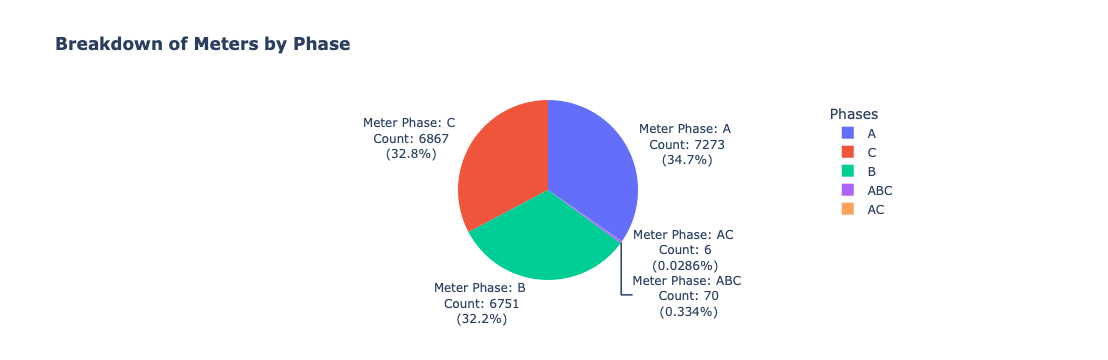

In [9]:
# Plot the number of meters per phase. 
fig = px.pie(df_meters_by_phases, 
             values='number_of_meters', names='phases',
             title='<b>Breakdown of Meters by Phase<b>',
             labels={'phase':'Meter Phase', 
                         'number_of_meters': 'Meter Count'})

# Show meter phase, meter count and percentage inside the pie chart.
fig.update_traces(texttemplate = 'Meter Phase: %{label} <br> Count: %{value:} <br>(%{percent})')
fig.update_layout(legend_title_text='Phases')

fig.show()

#### Meter Count by Consumer Type

In [10]:
# Unpack the data frame, group the results by consumer types, count the number of elements in each type and display the results. 
df_meters_by_consumer_types = (
    pd.json_normalize(grid_elements.to_dict('records'), record_path='results')
    .groupby(by='type_of_consumer')
    .count()
    .reset_index()[['type_of_consumer', 'id']]
    .rename(columns={'id': 'number_of_meters', 'type_of_consumer': 'consumer_type'})
)
df_meters_by_consumer_types

,consumer_type,number_of_meters
0,business,722
1,industrial,52
2,residential,20193


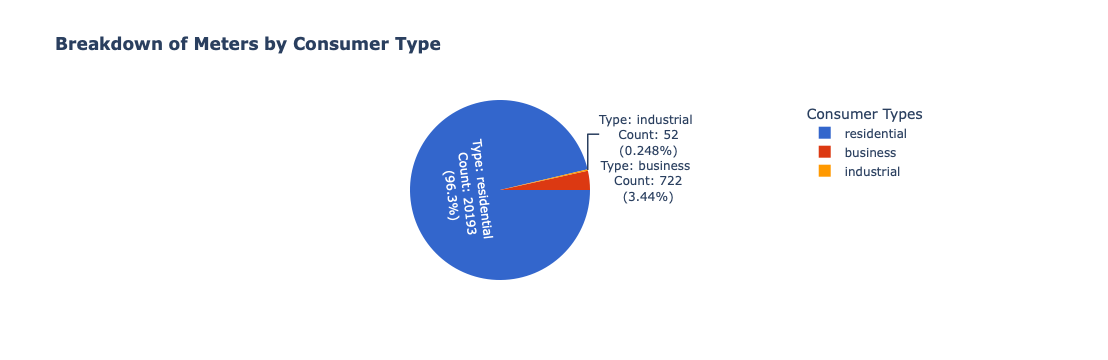

In [11]:
# Plot the number of meters per consumer type. 
fig = px.pie(df_meters_by_consumer_types, 
             values='number_of_meters', names='consumer_type',
             title='<b>Breakdown of Meters by Consumer Type<b>',
             color_discrete_sequence=px.colors.qualitative.G10,
             labels={'consumer_type':'Consumer Type', 
                         'number_of_meters': 'Meter Count'})

# Show consumer type, meter count and percentage inside the pie chart.
fig.update_traces( texttemplate = 'Type: %{label} <br> Count: %{value:} <br>(%{percent})', rotation=90)
fig.update_layout(legend_title_text='Consumer Types')

fig.show()

#### Meter Count by both Phase and Consumer Type

In [12]:
# Unpack the data frame, group the results by phases and consumer type, count the number of elements in each category and display the results. 
df_meters = (
    pd.json_normalize(grid_elements.to_dict('records'), record_path='results')
    .groupby(by=['phases', 'type_of_consumer'])
    .count()
    .reset_index()[['phases', 'type_of_consumer', 'id']]
    .rename(columns={'id': 'number_of_meters', 'type_of_consumer': 'consumer_type'})
    .sort_values(by='phases', key=lambda x: x.str.len(), ascending=False)
)
df_meters

,phases,consumer_type,number_of_meters
3,ABC,business,23
4,ABC,industrial,46
5,ABC,residential,1
6,AC,business,2
7,AC,industrial,3
8,AC,residential,1
0,A,business,224
1,A,industrial,2
2,A,residential,7047
9,B,business,245


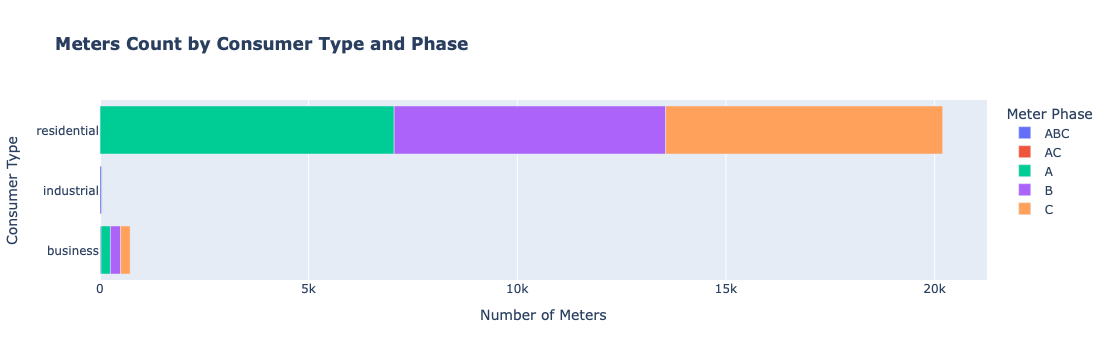

In [13]:
# Plot the breakdown of meters per phase and per consumer type. 
fig = px.bar(df_meters, x='number_of_meters', y='consumer_type', color='phases', orientation='h',
             title='<b>Meters Count by Consumer Type and Phase<b>', 
             labels={'consumer_type':'Consumer Type', 
                         'number_of_meters': 'Number of Meters', 
                         'phases':'Meter Phase'})
fig.show()

---